In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import wandb
import torch

In [139]:
from inference_visualization import download_model_and_config, build_esn_from_config, generate_series_using_dataset, load_model, mask_and_predict

In [140]:
run_id = '8mrjpiu1'

In [142]:
model_path, config = download_model_and_config(run_id)
config['esn_store_state'] = True
config['dataset']['val']['num_series'] = 1_000
model = load_model(model_path, config)
model.to('cuda')
dataloader = generate_series_using_dataset(config, num_series=1)

In [143]:
serieses = []
inputs = []
for x, y in tqdm(dataloader):
    serieses.append(x.cpu().numpy())
    inputs.append(dataloader.dataset.esn.input)

 29%|██▉       | 294/1000 [00:05<00:13, 50.75it/s]


KeyboardInterrupt: 

In [118]:
serieses = [x.flatten() for x in serieses]

In [103]:
inputs = [np.concatenate(x) for x in inputs]

In [104]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

stats = {
    'mean': [],
    'volatility': [],
    'dynamic_range': [],
    'skewness': [],
    'kurtosis': [],
    'autocorr_lag1': [],
    'autocorr_lag10': []
}

for x in inputs:
    x = np.asarray(x).ravel()
    T = len(x)

    # 1. Mean
    mu = np.mean(x)
    stats['mean'].append(mu)

    # 2. Volatility (variance)
    vol = np.var(x, ddof=0)
    stats['volatility'].append(vol)

    # 3. Dynamic range (peak-to-peak)
    dyn_rng = np.ptp(x)
    stats['dynamic_range'].append(dyn_rng)

    # 4. Skewness
    sk = skew(x)
    stats['skewness'].append(sk)

    # 5. Excess Kurtosis
    kurt = kurtosis(x, fisher=True)
    stats['kurtosis'].append(kurt)

    # 6. Short-memory persistence (lag-1 autocorrelation)
    if T > 1:
        ac1 = np.corrcoef(x[:-1], x[1:])[0, 1]
    else:
        ac1 = np.nan
    stats['autocorr_lag1'].append(ac1)

    # 7. Long-memory persistence (lag-10 autocorrelation)
    if T > 10:
        ac10 = np.corrcoef(x[:-10], x[10:])[0, 1]
    else:
        ac10 = np.nan
    stats['autocorr_lag10'].append(ac10)

# Build DataFrame of raw concept values
df_concepts = pd.DataFrame(stats)

In [105]:
np.quantile(df_concepts.values, [0.1, 0.9], axis=0).shape

(2, 7)

In [106]:
from einops import rearrange

In [107]:
quantiles = np.quantile(df_concepts.values, [0.01, 0.99], axis=0)

In [108]:
features = df_concepts.values

In [109]:
high_feature_quantile = features > quantiles[1, :]

In [110]:
low_feature_quantile = features < quantiles[0, :]

In [136]:
high_mean = [x for x, mask in zip(inputs, high_feature_quantile[:, 3]) if mask]
low_mean = [x for x, mask in zip(inputs, low_feature_quantile[:, 3]) if mask]

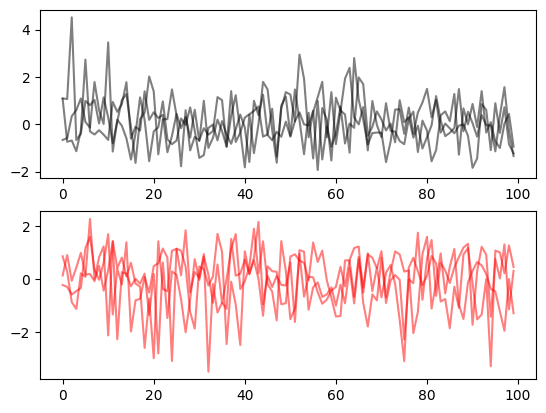

In [137]:
fig, (ax1, ax2) = plt.subplots(2)
for s in high_mean[:3]:
    ax1.plot(s, alpha=0.5, color='black')
for s in low_mean[:3]:
    ax2.plot(s, alpha=0.5, color='red')